# Science Advances

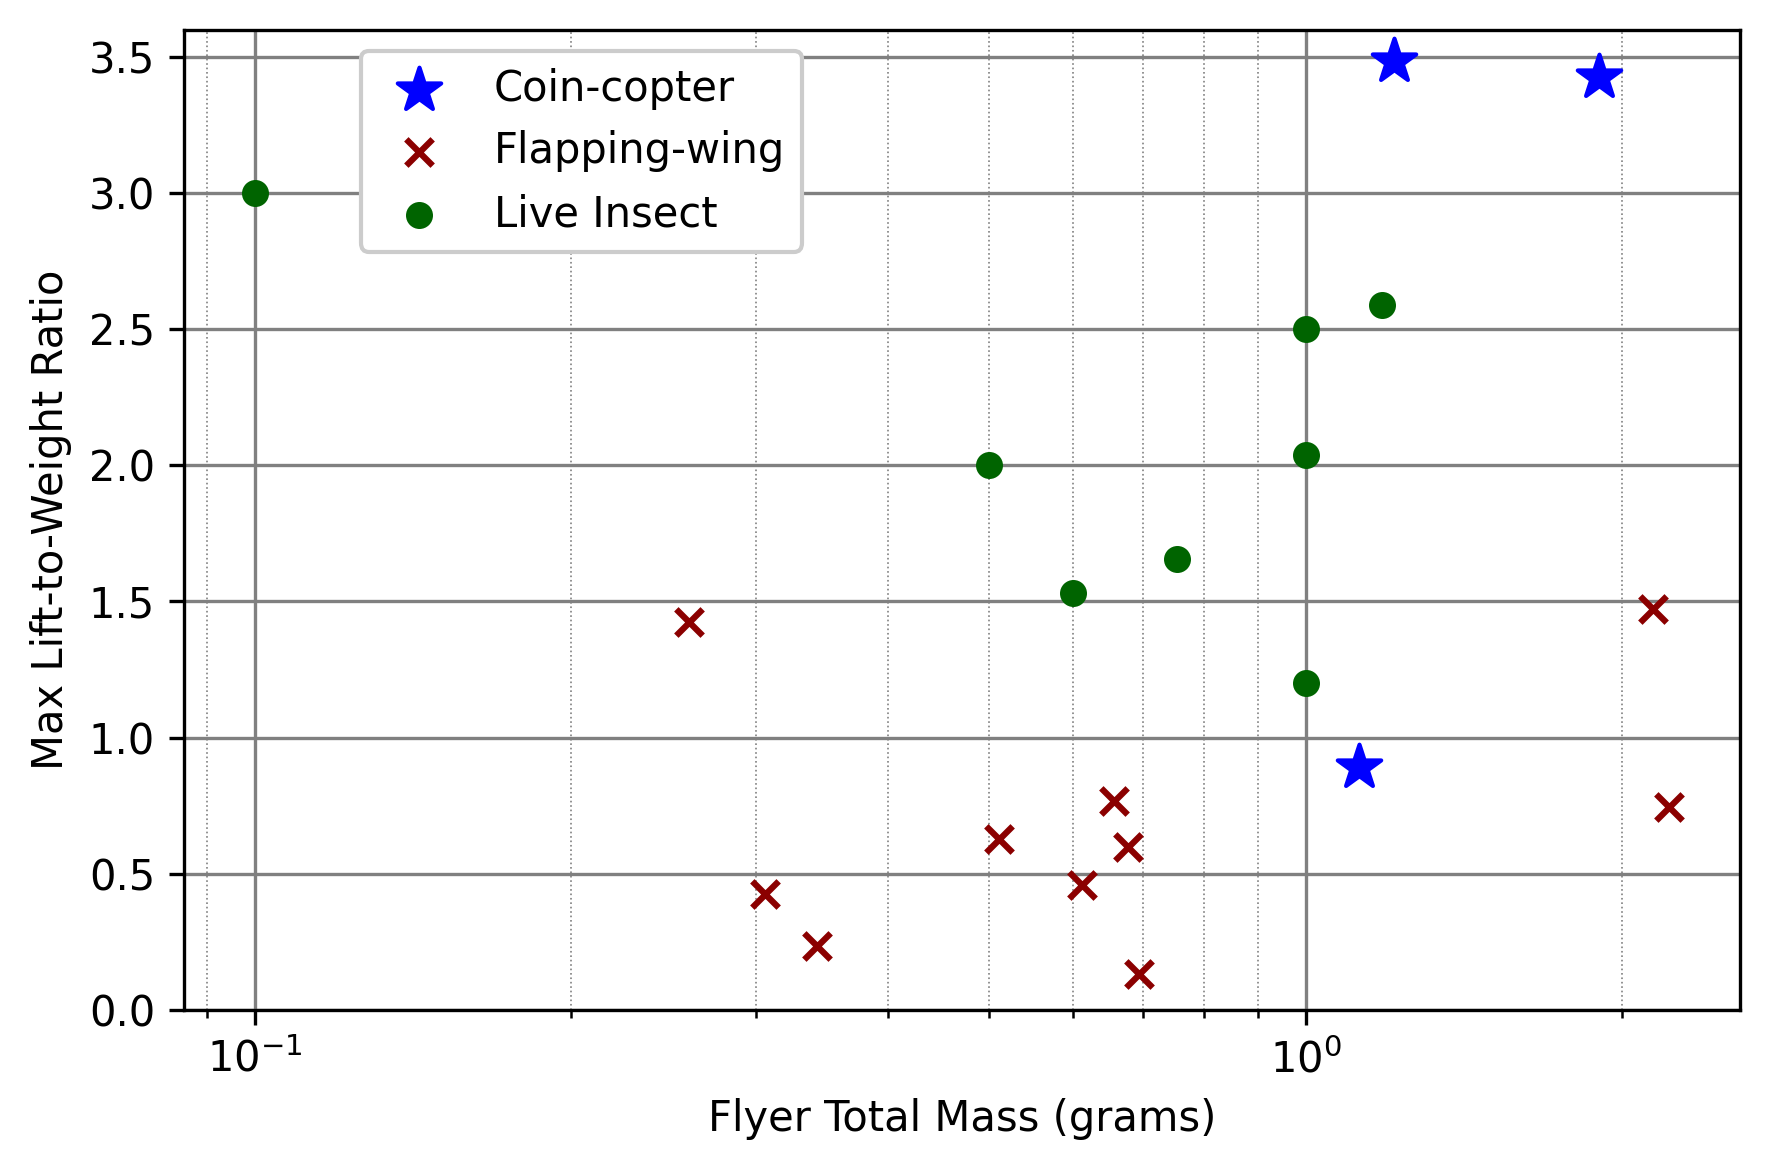

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# Load data from Google Sheet.
sheet_id = '1LFHIpymT5-N-PmtqGEGKend8cGQ8re5htjovim-ByKg'
gid = '350481859'
sheet_url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}'
df = pd.read_csv(sheet_url)

# Clean data: convert columns to numeric and drop rows with missing values.
df['Mass (grams)'] = pd.to_numeric(df['Mass (grams)'], errors='coerce')
df['Max Lift (grams)'] = pd.to_numeric(df['Max Lift (grams)'], errors='coerce')
# Convert the power electronics mass column to numeric.
df['Additional Power Electronics (grams)'] = pd.to_numeric(df['Additional Power Electronics (grams)'], errors='coerce')
df.dropna(subset=['Mass (grams)', 'Max Lift (grams)'], inplace=True)

# Add the Additional power electronics mass to the "Mass (grams)".
# If the Additional power electronics mass is missing, fill with 0.
df['Mass (grams)'] = df['Mass (grams)'] + df['Additional Power Electronics (grams)'].fillna(0)

# Compute Lift-to-Weight Ratio using the updated mass.
df['Max Lift-to-Weight Ratio'] = df['Max Lift (grams)'] / df['Mass (grams)']

# Define marker and color dictionaries.
marker_dict = {
    "Coin-copter": "*",
    "Flapping-wing": "x",
    "Live Insect": "o"
}
color_dict = { # make text darker or gray (add alpha value)
    "Coin-copter": "blue",    # blue
    "Flapping-wing": "darkred",  # red
    "Live Insect": "darkgreen"    # green
}

# Create the plot (initially on a linear scale).
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Define the desired order for the legend
desired_order = ["Coin-copter", "Flapping-wing", "Live Insect"]
if set(desired_order) != set(df['Type'].unique()):
    print("Adjust the desired_order list to match the imported spreadsheet")

# Plot each type with its assigned marker and color.
for t in desired_order:
    subset = df[df['Type'] == t]
    marker = marker_dict.get(t, 'o')
    color = color_dict.get(t, "C0")
    if marker == '*':
      size = 120
      #print(subset['Max Lift-to-Weight Ratio'])
    elif marker == 'o':
      size = 30
    else:
      size = 40
    ax.scatter(subset['Mass (grams)'], subset['Max Lift-to-Weight Ratio'],
               marker=marker, color=color, s=size, label=t, zorder=5)
    # Annotate each point with a fixed pixel offset.
    # for idx, row in subset.iterrows():
    #     ax.annotate(
    #         text=row['Name'],
    #         xy=(row['Mass (grams)'], row['Max Lift-to-Weight Ratio']),
    #         xytext=(5, -5),  # Fixed offset: 5 pixels right, 5 pixels down.
    #         textcoords='offset points',
    #         fontsize=8,
    #         color=color,
    #         ha='left',
    #         va='center',
    #         bbox=dict(facecolor='white', alpha=1.0, edgecolor='none', pad=0.5),
    #         clip_on=True
    #     )

# Switch to log–log scale axes.
ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_xlabel("Flyer Total Mass (grams)")
ax.set_ylabel("Max Lift-to-Weight Ratio")
ax.set_yticks([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5])
ax.set_ylim(0, 3.6)
ax.set_axisbelow(True)
ax.tick_params(axis='y', which='minor', left=False, right=False)

# Set minor tick locators.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs='auto', numticks=10))

# Add grid lines.
ax.grid(which="major", linestyle='-', linewidth=0.8, color='grey')
ax.grid(which="minor", linestyle=':', linewidth=0.4, color='grey', axis="x")
ax.legend(facecolor='white', framealpha=1, loc='upper left', bbox_to_anchor=(0.1, 1.00)) # edgecolor='black',
plt.tight_layout()
plt.show()
out_path = '/content/lift-vs-mass.svg'
fig.savefig(out_path, format='svg', dpi=300, bbox_inches='tight', transparent=True, facecolor='none', edgecolor='none')
from google.colab import files
files.download(out_path)
plt.show()